# Exporting a jeanie halo to galpy, agama or galax

A solved halo is a set of callables — `rho(R,z)`, `M(<r)`, `g_r(r)`, `Phi(r)`.
Each orbit library wants a different one of them, in different units, and
getting the units wrong is **silent**: a mis-scaled potential still integrates
orbits, it just integrates the wrong ones. `jeanie.export` does those
conversions in one place and the round trips are asserted in
`tests/test_export.py`.

Two things to know before using any of this:

**Baryons.** `mass_fn`, `radial_acceleration_fn` and `potential_fn` are *dark
matter only* — the baryons shape the halo through `Phi_b` but are not added to
it. For an orbit you want the total, so `baryons=True` is the default in the
exporters and adds the Miyamoto–Nagai disc already carried in `params`.
Forgetting it is silent; the tell is that an orbit outside `r1` has exactly
zero gradient with respect to `Md`, `a` and `b`.

**Which exporter for which job.**

| target | route | accuracy |
|---|---|---|
| galpy, spherical | `interpSphericalPotential` from the exact force | 1.2e-7 |
| galpy, flattened | SCF basis expansion | **22% — does not converge, see below** |
| agama | `Multipole` from the density callable | native, no basis |
| galax | JAX potential wrapping `Phi` | exact, and differentiable |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from jeanie.export import callables, to_galpy, to_agama, to_galax

# [M200, c, r1, Md, a, b]  -- Msun, dimensionless, kpc, Msun, kpc, kpc
params = np.array([1.0e12, 10.0, 15.0, 6.0e10, 3.0, 0.28])
fns = callables(params)
print({k: type(v).__name__ for k, v in fns.items()})

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


{'rho': 'function', 'M': 'function', 'g': 'function', 'Phi': 'function'}


## The framework-agnostic export

`callables()` is the escape hatch: four plain JAX functions, differentiable in
the halo parameters. If your framework is not one of the three below, wrapping
these is less work than fighting a converter.

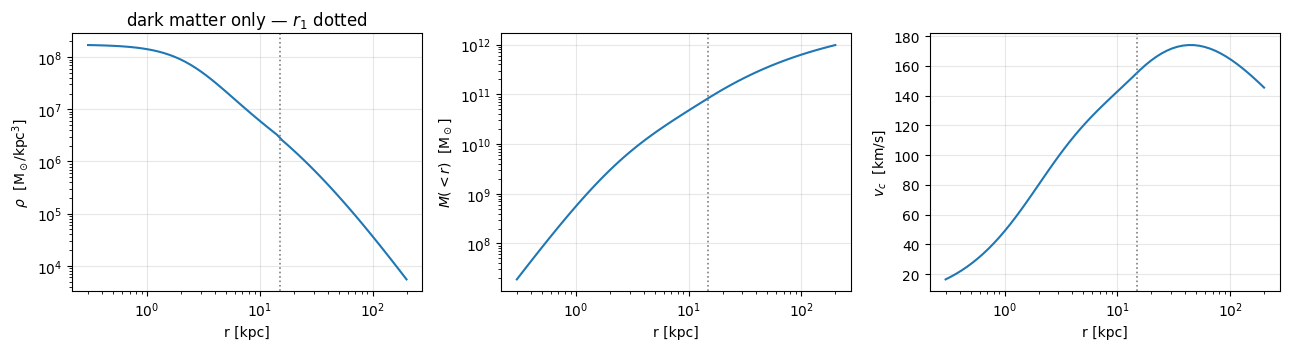

In [2]:
r = np.geomspace(0.3, 200.0, 60)
rho = np.array([float(fns["rho"](x, 0.0)) for x in r])
M   = np.array([float(fns["M"](x)) for x in r])
vc  = np.sqrt(4.302e-6 * M / r)

fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
ax[0].loglog(r, rho); ax[0].set(xlabel="r [kpc]", ylabel=r"$\rho$  [M$_\odot$/kpc$^3$]")
ax[1].loglog(r, M);   ax[1].set(xlabel="r [kpc]", ylabel=r"$M(<r)$  [M$_\odot$]")
ax[2].semilogx(r, vc); ax[2].set(xlabel="r [kpc]", ylabel=r"$v_c$  [km/s]")
for a_ in ax: a_.axvline(params[2], color="grey", ls=":", lw=1.2); a_.grid(alpha=.3)
ax[0].set_title("dark matter only — $r_1$ dotted")
fig.tight_layout()

## galpy

`kind="spherical"` builds an `interpSphericalPotential` from the exact radial
force. The check below is the one that matters: galpy's *own* force evaluation
against jeanie's, which is where a unit error would show.

In [3]:
from galpy.potential import evaluateRforces
ro, vo = 8.0, 220.0
F0 = vo**2 / ro                      # galpy's internal force unit

pot_dm = to_galpy(params, ro=ro, vo=vo, kind="spherical", baryons=False)
print(f"{'r [kpc]':>9s} {'jeanie g_r':>13s} {'galpy g_r':>13s} {'rel':>9s}")
for x in (1.0, 5.0, 20.0, 60.0, 150.0):
    gj = float(fns["g"](x))
    gg = float(evaluateRforces(pot_dm, x/ro, 0.0, use_physical=False)) * F0
    print(f"{x:9.1f} {gj:13.5e} {gg:13.5e} {abs(gg/gj-1):9.2e}")

  r [kpc]    jeanie g_r     galpy g_r       rel
      1.0  -2.39168e+03  -2.39168e+03  1.17e-07
      5.0  -2.87827e+03  -2.87827e+03  3.37e-08
     20.0  -1.34016e+03  -1.34016e+03  5.80e-09
     60.0  -4.96841e+02  -4.96841e+02  2.03e-08
    150.0  -1.58434e+02  -1.58434e+02  3.69e-08


### With baryons, and an orbit

`baryons=True` returns the combined potential. Note how much the disc changes
the inner rotation curve — this is the term it is easy to forget.

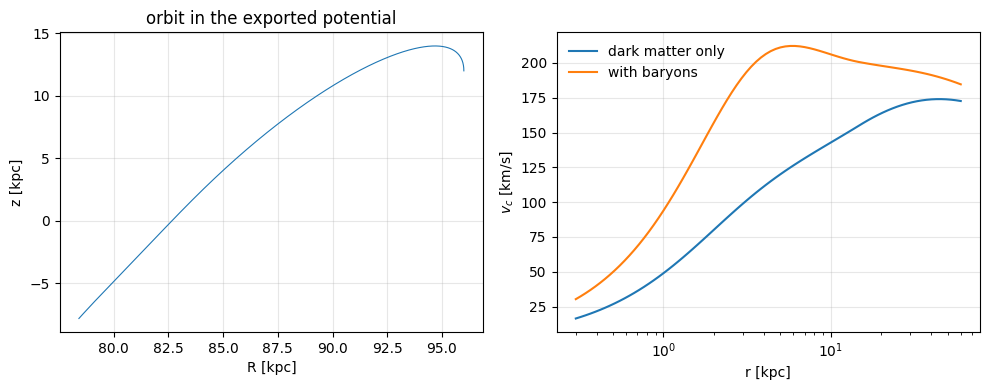

In [4]:
pot = to_galpy(params, ro=ro, vo=vo, baryons=True)

from galpy.orbit import Orbit
o = Orbit([12.0/ro, 0.0, 180.0/vo, 1.5/ro, 20.0/vo, 0.0], ro=ro, vo=vo)
ts = np.linspace(0.0, 3.0, 3000)     # Gyr
o.integrate(ts * 1.0227, pot)        # galpy time unit at ro=8, vo=220

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(o.R(ts*1.0227)*ro, o.z(ts*1.0227)*ro, lw=.8)
ax[0].set(xlabel="R [kpc]", ylabel="z [kpc]", title="orbit in the exported potential")
rr = np.geomspace(0.3, 60, 80)
vdm = np.array([np.sqrt(-float(evaluateRforces(pot_dm, x/ro, 0., use_physical=False))*F0*x) for x in rr])
vto = np.array([np.sqrt(-float(evaluateRforces(pot,    x/ro, 0., use_physical=False))*F0*x) for x in rr])
ax[1].plot(rr, vdm, label="dark matter only"); ax[1].plot(rr, vto, label="with baryons")
ax[1].set(xscale="log", xlabel="r [kpc]", ylabel=r"$v_c$ [km/s]"); ax[1].legend(frameon=False)
for a_ in ax: a_.grid(alpha=.3)
fig.tight_layout()

### What does *not* work: `kind="scf"`

galpy's SCF route keeps the flattening but **does not converge on this
profile**. Measured density error against jeanie: 49% median at (N,L)=(8,6),
27% at (20,10), 22% at (30,12).

The fault is the basis, not the plumbing — the identical call reproduces a
Hernquist density to 1e-15. A thermalised core matched to an Einasto envelope
has a kink at `r1` that a smooth Hernquist expansion cannot follow. For a
flattened halo use agama, whose `Multipole` is built from the density directly
and has no basis to fight.

## agama

agama takes the density callable directly, so there is no basis-convergence
problem. One caveat worth knowing: **agama's unit system is global**, so
`to_agama` sets it to (Msun, kpc, km/s) and that affects every other agama
object in the session. That is agama's design, and it is the usual cause of
silently wrong results when mixing sources.

In [5]:
try:
    pot_ag = to_agama(params)
    xyz = np.column_stack([np.geomspace(1, 60, 6), np.zeros(6), np.zeros(6)])
    print("agama potential:", pot_ag)
    print("rho along x:", pot_ag.density(xyz))
except ImportError as e:
    print("agama not installed here —", e)
    print("pip install agama   (it compiles C++, so expect a few minutes)")

agama not installed here — No module named 'agama'
pip install agama   (it compiles C++, so expect a few minutes)


## galax

The reason to export to galax rather than galpy is **end-to-end
differentiability**: the `Phi` it wraps is the same traced JAX function
`jaxprofile` produces, so `d(orbit)/d(halo parameters)` works without finite
differences.

In [6]:
try:
    pot_gx = to_galax(params)
    print("galax potential:", pot_gx)
except ImportError as e:
    print("galax not installed here —", e)
    print("pip install galax")
except RuntimeError as e:
    print("galax API drift:", e)

galax not installed here — to_galax needs galax (pip install galax). For any other framework use jeanie.export.callables(params), which returns plain JAX rho/M/g/Phi.
pip install galax


### Differentiability, without galax

The gradient is a property of `callables()`, not of any wrapper — so it works
regardless of which libraries are installed.

In [7]:
import jax
from jeanie.jaxprofile import potential_fn

grad = jax.grad(lambda q: potential_fn(q)(20.0))(params)
names = ["M200", "c", "r1", "Md", "a", "b"]
print("dPhi(20 kpc) / dparam:")
for n, g in zip(names, np.asarray(grad)):
    print(f"  {n:5s} {float(g):+.4e}")
print("\nNote Md, a, b are ~0: potential_fn is DARK MATTER ONLY.")
print("That zero is exactly the tell for the baryon trap described at the top.")

dPhi(20 kpc) / dparam:
  M200  -7.0500e-08
  c     -1.8743e+03
  r1    -2.4330e+02
  Md    +0.0000e+00
  a     +0.0000e+00
  b     +0.0000e+00

Note Md, a, b are ~0: potential_fn is DARK MATTER ONLY.
That zero is exactly the tell for the baryon trap described at the top.
